In [2]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.tools import Tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.types import Command
from langgraph.checkpoint.memory import MemorySaver
from pydantic import BaseModel, Field
from typing import Literal, List, TypedDict, Annotated
from dotenv import load_dotenv
import warnings
warnings.filterwarnings("ignore")
load_dotenv()

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.1)


def build_internal_rag(file_path:str):
    document=PyPDFLoader(file_path).load()

    chunks=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(document)

    embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

    vectordb=FAISS.from_documents(chunks,embeddings)

    retriever=vectordb.as_retriever(search_type="mmr",search_kwargs={"k": 6,"fetch_k":10,"lambda_mult": 0.25})

    def retrieved_data(query):
        retrieved_chunks=retriever.invoke(query)
        retrieved_context="\n\n".join(doc.page_content for doc in retrieved_chunks)

        return retrieved_context
    return Tool(name="Internaldata",description="Use this tool to answer questions related to the GEN AI book. "
            "It retrieves relevant content from the document",func=retrieved_data)

internal_data_tool=build_internal_rag("D:\GEN AI Practice\data\GEN AI Book.pdf")
internal_data_tool




<>:42: SyntaxWarning: invalid escape sequence '\G'
<>:42: SyntaxWarning: invalid escape sequence '\G'
C:\Users\colle\AppData\Local\Temp\ipykernel_12752\2301996507.py:42: SyntaxWarning: invalid escape sequence '\G'
  internal_data_tool=build_internal_rag("D:\GEN AI Practice\data\GEN AI Book.pdf")
d:\GEN AI Practice\venu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 556.04it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Tool(name='Internaldata', description='Use this tool to answer questions related to the GEN AI book. It retrieves relevant content from the document', func=<function build_internal_rag.<locals>.retrieved_data at 0x000001D4987C98A0>)

In [3]:
def router(last_message:str,goto:str):
    if "### Final Answer" in last_message:
        return END
    return goto

In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily=TavilySearchResults(max_results=2)
tools=[tavily,internal_data_tool]

research_agent = create_react_agent(
    llm,
    tools=tools,
    prompt="""
You are a helpful AI Research Assistant.

Your job is to research the user's question using the available tools.
You are working with another colleague agent who is responsible for generating the final response.

Tool Usage Guidelines:
- Use Tavily search for general knowledge or recent information
- Use InternalData tool for questions related to the GEN AI book

Your responsibilities:
- Gather relevant and accurate information
- Use tools when needed
- Return useful research findings only
- Do not generate the final polished answer
- Focus on facts, explanations, and supporting details

Output Format:
- Key Points
- Important Details
- Examples (if any)

IMPORTANT:
- When research is complete, end your response with "### Final Answer"

Be concise, relevant, and accurate.
"""
)   

In [6]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage

def research_node(state: MessagesState) -> Command[Literal["blog_generator_agent", END]]:
    research_result = research_agent.invoke({"messages": state["messages"]})
    last_message = research_result["messages"][-1].content
    goto = router(last_message, "blog_generator_agent")

    research_result["messages"][-1] = AIMessage(
        content=last_message,
        name="researcher_agent"
    )

    return Command(
        update={"messages": research_result["messages"]},
        goto=goto
    )

In [7]:
generate_agent = create_react_agent(
    llm,
    tools=[],
    prompt="""

You are an expert Blog Writer Agent.

Your job is to generate a polished, engaging, and well-structured blog using the research already available in the conversation.

Instructions:
- Use the provided research only
- Write a compelling title
- Add a clear introduction
- Organize the content with headings and sections
- Use markdown formatting for headings and sections
- Keep the writing informative, natural, and easy to read
- Include useful explanations or examples when appropriate
- End with a concise conclusion
- Do not perform new research
- Do not mention tools, agents, or internal workflow

IMPORTANT:
- If the messages already contain "### Final Answer", do not generate anything and return the existing result.

Output only the final polished blog.
""")

In [8]:
def generator_node(state: MessagesState) -> Command[Literal[END]]:
    generate_result = generate_agent.invoke({"messages": state["messages"]})
    last_message = generate_result["messages"][-1].content

    generate_result["messages"][-1] = AIMessage(
        content=last_message,
        name="blog_generator_agent"
    )

    return Command(
        update={"messages": generate_result["messages"]},
        goto=END
    )

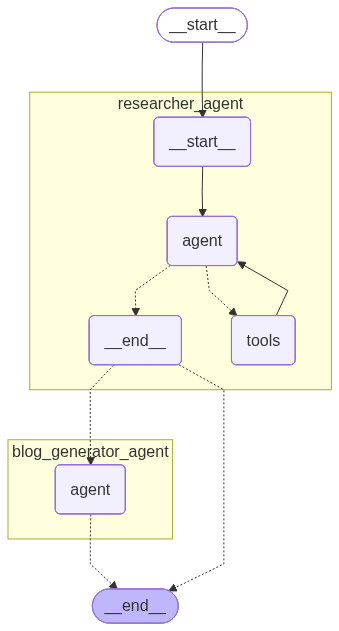

In [9]:
workflow=StateGraph(MessagesState)
workflow.add_node("researcher_agent",research_node)
workflow.add_node("blog_generator_agent",generator_node)

workflow.set_entry_point("researcher_agent")
workflow.add_edge("researcher_agent","blog_generator_agent")
workflow.add_edge("blog_generator_agent",END)
graph=workflow.compile()
from IPython.display import display,Image

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [10]:
from langchain_core.messages import HumanMessage

result = graph.invoke({
    "messages": [
        HumanMessage(content="Write a detailed blog about Gen AI")
    ]
})

In [12]:
#Final Blog Generation
print(result["messages"][-1].content)


# Introduction to Gen AI
Gen AI, or Generative Artificial Intelligence, is a type of artificial intelligence that can create original content such as text, images, video, audio, or software code in response to a user's prompt or request. It relies on sophisticated machine learning models called deep learning models that simulate the learning and decision-making processes of the human brain.

## What is Gen AI?
Gen AI is a form of predictive artificial intelligence that uses large data sets to train the technology, which the model consults when determining the best possible answer to a prompt. It can create code blocks by comparing them to a library of similar information and predict the rest of the code a developer begins to type.

## Applications of Gen AI
Gen AI has various applications across industries, including:
* Health care: discovering and developing new life-saving medicine, personalizing treatment plans for individual patients, and creating predictive images for charting di